# **Esame del 17 luglio 2025**

- Non si possono consultare libri, note, ed ogni altro materiale o persone durante
l’esame ad eccezione delle funzioni Python fornite.

- Risolvere i seguenti esercizi con l’ausilio di Python.

- La durata del compito è di 90 minuti.

- Questo esame ha 3 domande, per un totale di 30/30 punti.

- Svolgere gli esercizi marcati con **[T]** su fogli protocollo, indicando: nome, cognome, codice persona
e data

# **Esercizio 1 (punti 10)**

Si consideri $x$ come un set di punti associato a una distribuzione equispaziata di $N$ nodi nell’intervallo $[0, 2\pi]$.
Ad $x$ vengono associati i seguenti dati:

- `y_true`: valutazione della funzione seno
- `y_noisy`: valutazione della funzione seno soggetta ad un rumore aleatorio aggiuntivo

Entrambi possono essere associati sfruttando il seguente script:

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Set seed for reproducibility
np.random.seed(0)

# Original data points (sine function)
N = 10
x = np.linspace(0, 2 * np.pi, N)
y_true = np.sin(x)

# Add Gaussian noise
noise = np.random.normal(scale=0.1, size=x.shape)
y_noisy = y_true + noise

#### **(1a) (1 punti) [P]**  

Rappresentare graficamente i dati forniti confrontando la `y_true` con la `y_noisy`.

##### **Soluzione.**

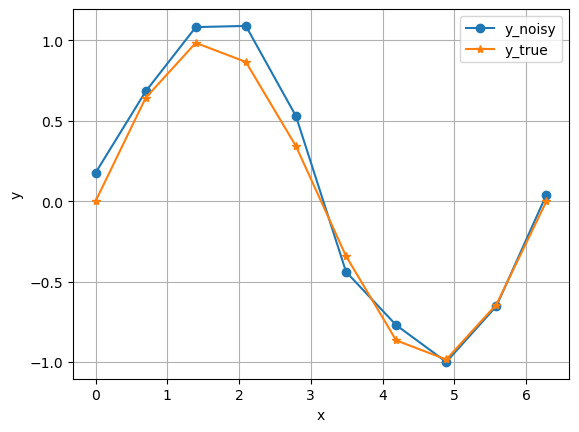

In [2]:
plt.plot(x, y_noisy, '-o')
plt.plot(x, y_true,'-*')

plt.xlabel('x')
plt.ylabel('y')
plt.legend(['y_noisy', 'y_true'])
plt.grid()
plt.show()

#### **(1b) (3 punti) [T]**  

Si discuta il problema dell'interpolazione polinomiale e si derivi l'espressione del polinomio interpolante Lagrangiano.

##### **Soluzione.**

Vogliamo affrontre il problema che consiste nel trovare,  dato un set di
punti $(x_i,y_i)$, una funzione interpolante ossia una funzione che passa per tutti i punti
dati.

Date $n+1$ coppie di punti $(x_i, y_i)$ distinte, per $i=0, \ldots, n$, cerco un
polinomio di grado $n$ chiamato $\pi_n \in \mathbb{P}^n$, con $\mathbb{P}^n$
lo spazio dei polinomi fino al grado $n$, che passi per gli $n+1$ punti, ovvero,
tale che soddisfi
\begin{gather*}
    \pi_n(x_i) = y_i \quad i=0,\ldots,n.
\end{gather*}
tale polinomio esiste ed è unico.

Definisco quindi per ogni $i=0,\ldots,n$ un polinomio $\mathcal{L}_i$ di
grado $n$ con le seguenti caratteristiche:
\begin{gather*}
    \mathcal{L}_i(x_k) =
    \begin{cases}
        1 & \text{se }k=i\\
        0 & \text{se }k \neq i
    \end{cases}
    \quad \rightarrow \quad
    \mathcal{L}_i(x) = \prod_{j=0, j\neq i}^n \frac{x-x_j}{x_i-x_j}
\end{gather*}
tali polinomi sono detti polinomi caratteristici di Lagrange
I polinomi $\mathcal{L}_i$ sono linearmente indipendenti.

Date le proprietà dei polinomi di Lagrange, allora possiamo costruire
l'interpolante polinomiale $\pi_n(x)$ tale che $\pi_n(x_i) = y_i$ nel
seguente modo
\begin{gather*}
    \pi_n(x) = \sum_{i=0}^n y_i \mathcal{L}_i(x),
\end{gather*}
detto interpolante polinomiale Lagrangiano.

#### **(1c) (3 punti) [P]**  

Interpolare i valori di `y_true` e `y_noisy`. Rappresentando graficamente i polinomi interpolanti, cosa si osserva? Commentare i risultati ottenuti.


##### **Soluzione.**

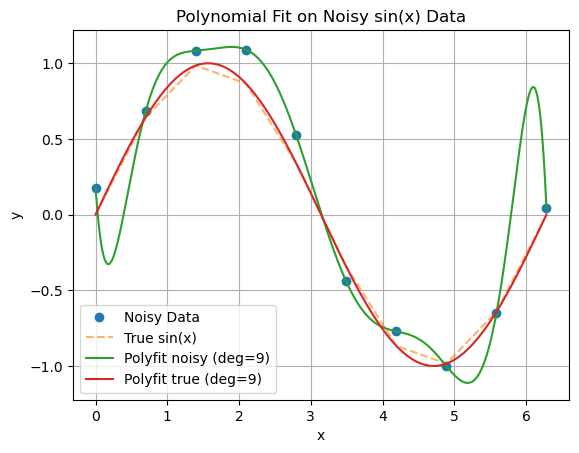

In [3]:
N_interp = 300
x_fine = np.linspace(0, 2 * np.pi, N_interp)

degree = x.size-1
coeffs_noisy = np.polyfit(x, y_noisy, degree)
y_noisy_interp = np.polyval(coeffs_noisy, x_fine)

coeffs_true = np.polyfit(x, y_true, degree)
y_true_interp = np.polyval(coeffs_true, x_fine)

plt.plot(x, y_noisy, 'o', label='Noisy Data')
plt.plot(x, y_true, '--', label='True sin(x)', alpha=0.6)
plt.plot(x_fine, y_noisy_interp, '-', label=f'Polyfit noisy (deg={degree})')
plt.plot(x_fine, y_true_interp, '-', label=f'Polyfit true (deg={degree})')
plt.legend()
plt.grid(True)
plt.title("Polynomial Fit on Noisy sin(x) Data")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

Osserviamo che il polinomio interpolatore applicato ai dati rumorosi manifesta oscillazioni agli estremi dell'intervallo e, pertanto, non rappresenta una via ottimale per descrivere i dati.

#### **(1d) (3 punti) [P+T]**  

Lasciando inalterato $x$, proporre una strategia di approssimazione dei dati che mitiga la presenza del rumore e ripetere il punto precedente con la soluzione proposta.

##### **Soluzione.**

Possiamo adottare un'approssimazione ai minimi quadrati, scegliendo quindi il grado del polinomio approssimante minore rispetto alla lunghezza dei dati.

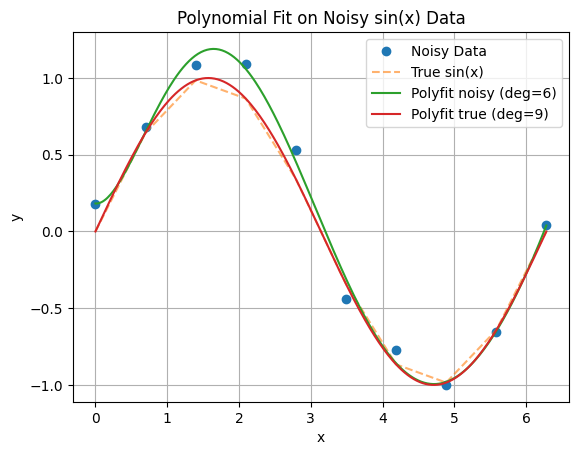

In [11]:
N_interp = 300
x_fine = np.linspace(0, 2 * np.pi, N_interp)

degree = x.size-1
degree_mq = degree-3

coeffs_noisy = np.polyfit(x, y_noisy, degree_mq)
y_noisy_interp = np.polyval(coeffs_noisy, x_fine)

coeffs_true = np.polyfit(x, y_true, degree)
y_true_interp = np.polyval(coeffs_true, x_fine)


plt.plot(x, y_noisy, 'o', label='Noisy Data')
plt.plot(x, y_true, '--', label='True sin(x)', alpha=0.6)
plt.plot(x_fine, y_noisy_interp, '-', label=f'Polyfit noisy (deg={degree_mq})')
plt.plot(x_fine, y_true_interp, '-', label=f'Polyfit true (deg={degree})')
plt.legend()
plt.grid(True)
plt.title("Polynomial Fit on Noisy sin(x) Data")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

Diminuendo il grado di approssimazione del polinomio riusciamo a filtrare il rumore ed ottenere una buona approssimazione dei dati.

# **Esercizio 2 (10 punti)**


Si consideri il seguente problema di Cauchy:
\begin{gather*}
\left\{
    \begin{aligned}
        &y^\prime(t) = f(t, y(t)), \quad t \in (0,T] \\
        &y(0) = 1,
    \end{aligned}
    \right.
\end{gather*}

dove la funzione $f$ è definita come $f(t, y) = -10y$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from utilis_ODE import eulero_avanti

#### **(2a) (3 punti) [P]**

Verificare numericamente, per i seguenti valori del passo di discretizzazione $h=[0.1, 0.125, 0.2]$, se il metodo di Eulero in avanti risulta assolutamente stabile per il problema di Cauchy fornito. Si ponga il tempo finale pari a $T=2.5$. Cosa si osserva? Commentare i risultati ottenuti.

##### **Soluzione.**

Possiamo verificare che per i valori di $h$ forniti otteniamo il seguente comportamento della soluzione.

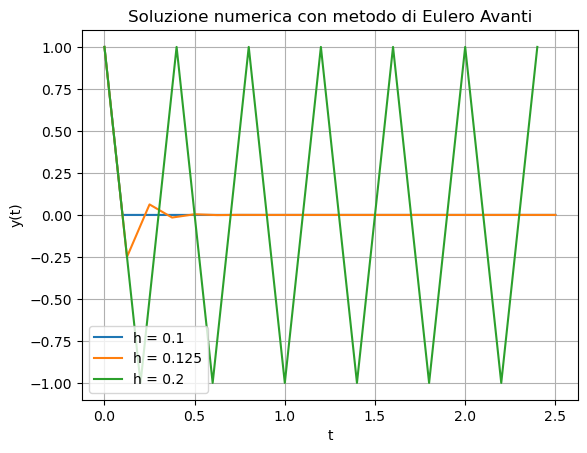

In [2]:
fun = lambda t, y: -10*y
y_0 = 1

t_0 = 0
t_N = 2.5
h_vals = [0.1, 0.125, 0.2]

for h in h_vals:
    t_n, u_n = eulero_avanti(fun, t_0, t_N, y_0, h)
    plt.plot(t_n, u_n)

plt.xlabel('t')
plt.ylabel('y(t)')
plt.title('Soluzione numerica con metodo di Eulero Avanti')
plt.legend([f'h = {h}' for h in h_vals])
plt.grid()
plt.show()

Si osserva che per i valori di $h=0.1$ e $h=0.125$ il metodo risulta assolutamente stabile e la soluzione decresce correttamente verso zero. Per $h=0.2$, invece, la soluzione numerica tende a oscillare senza convergere, mostrando un comportamento instabile anche per tempi grandi.

#### **(2b) (3 punti) [T]**

Si definisca l'assoluta stabilità per un metodo di avanzamento temporale applicato al problema di Cauchy modello. Inoltre, si derivi la condizione di assoluta stabilità per il metodo di Eulero in avanti.

##### **Soluzione.**

L'assoluta stabilità di uno schema numerico per la risoluzione di un problema
di Cauchy è un concetto di stabilità su intervalli illimitati. In altre parole vogliamo studiare cosa succede per $n\rightarrow \infty$ mantenendo $h$ fisso. Consideriamo il problema detto
problema modello seguente
\begin{gather*}
    \begin{cases}
        y^\prime(t) = \lambda y(t) \\
        y(0) = 1
    \end{cases}
\end{gather*}
dove $\lambda < 0$ è un parametro dato e per semplicità reale (si potrebbe estendere l'analisi a $\lambda$ complessi). La soluzione esatta del problema
modello è calcolabile analiticamente ed è pari a
\begin{gather*}
    y(t) = e^{\lambda t}
\end{gather*}
Un metodo numerico per la soluzione di un problema di Cauchy è
assolutamente stabile se, dato un passo $h$, otteniamo
\begin{gather*}
    \lim_{n\rightarrow \infty} u_n = 0
\end{gather*}
quando è applicato al problema modello discusso precedentemente.

Consideriamo il metodo di Eulero in avanti e applichiamolo al problema modello,
per $u_0=1$ abbiamo
\begin{gather*}
    u_{n+1} = u_n + h f(t_n, u_n) = u_n + h\lambda u_n = (1+h\lambda) u_n =
    (1+h\lambda)^2 u_{n-1} = \ldots = \\ = (1+h\lambda)^{n+1} u_0 =
    (1+h\lambda)^{n+1}.
\end{gather*}
Possiamo quindi scrivere che il metodo di Eulero in avanti genera la sequenza
delle soluzioni data da
\begin{gather*}
    u_n = (1+\lambda h)^n \quad \Rightarrow \quad \lim_{n\rightarrow\infty} u_n
    =  \lim_{n\rightarrow\infty} (1+\lambda h)^n = 0
    \quad \iff \quad \vert{1+h\lambda}\vert < 1.
\end{gather*}
Abbiamo quindi i seguenti casi da analizzare
\begin{gather*}
    1 + h \lambda < 1 \quad \rightarrow \quad h \lambda < 0 \quad \rightarrow
    \quad \forall h\\
    1 + h \lambda > -1 \quad \rightarrow \quad h \lambda > -2 \quad \rightarrow
    \quad h < \frac{2}{\vert{\lambda}\vert}
\end{gather*}
Quindi il metodo di Eulero in avanti risulta assolutamente stabile solo se
prendo $h$ sufficientemente piccolo, il metodo viene detto condizionatamente
assolutamente stabile.

#### **(2c) (4 punti) [P]**

Si implementi il seguente metodo di avanzamento temporale per risolvere il problema di Cauchy proposto, ponendo
\begin{gather}
    k_1 = f(t_n, u_n)\\
    k_2 = f(t_n + 0.5h, u_n + 0.5h k_1)\\
    k_3 = f(t_n + h, u_n + h (2k_2-k_1))
\end{gather}
Il calcolo della soluzione al passo seguente viene fatto sfruttando $u_{n+1} = u_n + h (k_1 + 4k_2 + k_3) / 6$, una traccia di implementazione è fornita di seguito.

Si verifichi se per i seguenti valori del passo di discretizzazione riportati precedentemente il metodo risulta assolutamente stabile.

In [3]:
def advancing_scheme(f, t0, tN, y0, h):
    N = int((tN - t0) / h)

    u_h = np.zeros(N+1)
    t_h = np.zeros(N+1)

    u_h[0] = y0
    t_h[0] = t0

    for i in np.arange(N):

        k_1 = # TODO
        k_2 = # TODO
        k_3 = # TODO

        u_h[i+1] = # TODO

        t_h[i+1] = t_h[i]+h

    return t_h, u_h

SyntaxError: invalid syntax (3973601310.py, line 12)

##### **Soluzione.**

Lo schema proposto è implementato nello script seguente.

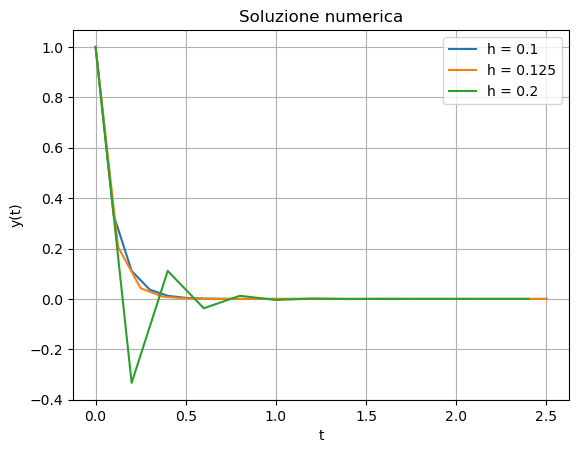

In [4]:
def advancing_scheme(f, t0, tN, y0, h):
    N = int((tN - t0) / h)

    u_h = np.zeros(N+1)
    t_h = np.zeros(N+1)

    u_h[0] = y0
    t_h[0] = t0

    for i in np.arange(N):

        k_1 = f(t_h[i], u_h[i])
        k_2 = f(t_h[i] + 0.5*h, u_h[i] + 0.5*h*k_1)
        k_3 = f(t_h[i] + h, u_h[i] + h*(2*k_2-k_1))

        u_h[i+1] = u_h[i]+ h*(k_1+4*k_2+k_3)/6

        t_h[i+1] = t_h[i]+h

    return t_h, u_h

for h in h_vals:
    t_n, u_n = advancing_scheme(fun, t_0, t_N, y_0, h)
    plt.plot(t_n, u_n)

plt.xlabel('t')
plt.ylabel('y(t)')
plt.title('Soluzione numerica')
plt.legend([f'h = {h}' for h in h_vals])
plt.grid()
plt.show()

Notiamo che il metodo proposto risulta essere assolutamente stabile per tutti i valori di $h$.

# **Esercizio 3 (10 punti)**

Assumendo $c>0$, si consideri la seguente equazione di conservazione

$$
\begin{cases}
  \partial_t c +\partial_x c = 0, & x\in (0,2),\ t\in(0,T], \\
  c(0,x) = e^{-40(x-0.5)^2}
    & x\in (0,2), \\
  c(t,0) = 0, & t\in (0,T]
\end{cases}
$$

dove il tempo finale è pari a $T=1$.

#### **(3a) (3 punti) [T]**

Illustrare brevemente il metodo dei volumi finiti per la soluzione numerica di tale equazione. Definire inoltre il flusso numerico upwind discutendo la sua applicabilità.

##### **Soluzione.**

Discutiamo la discretizzazione dell'equazione mediante il metodo dei
volumi finiti nel caso monodimensionale $c = c(x, t)$, in cui l'equazione è
\begin{gather*}
    \partial_t c + \partial_x f(c) = 0
    \quad \text{in} \quad
    \Omega.
\end{gather*}
Nel caso monodimensionale, sul dominio $\Omega= (a, b)$,
introduciamo una griglia computazionale che per semplicità assumiamo
equi-spaziata. Sia quindi $N$ il numero di suddivisioni o celle di $\Omega$ e
$h$ la lunghezza di ciascuna di esse. Indichiamo con $K_i$ la generica cella
$i$-esima .

Data una cella possiamo identificare il suo centro, il punto $x_{i}$, e il suo bordo che coincide con i due estremi associati $x_{i-\frac{1}{2}}=x_i-\frac{h}{2}$ e $x_{i+\frac{1}{2}}=x_i+\frac{h}{2}$, che connettono la cella $i$-esima a quella $i-1$ e $i+1$-esima, rispettivamente.
Definiamo inoltre una discretizzazione dell'intervallo temporale $[0,T]$ in intervalli di ampiezza $\Delta t$, tali per cui $t_n=n\Delta t$.
Dobbiamo ora definire i gradi di libertà associati alla variabile $c$ che
la rappresentano nel discreto. 
\begin{gather*}
    \dfrac{1}{|K_i|}\int_{K_i} c(x,t_n) = c_i^n\in \mathbb{R}
\end{gather*}
Una volta calcolati i valori di $c_i^n$, per ogni cella, possiamo
reinterpretare la soluzione come costante a tratti in tutta la cella stessa. E
quindi, a valle di questa reinterpretazione, possiamo anche dire che $c_i^n\in
\mathbb{P}_0(K_i)$. La soluzione numerica risulta quindi discontinua tra due
celle adiacenti che è una buona strategia in quanto le leggi di
conservazione possono sviluppare soluzioni discontinue anche in presenza di dati
iniziali continui.

Otteniamo quindi
\begin{gather*}
    c_i^n=\dfrac{1}{h}\displaystyle\int_{x_{i-\frac{1}{2}}}^{x_{i+\frac{1}{2}}}
    c(x,t_n) dx.
\end{gather*}
La soluzione numerica sarà quindi costante a tratti sulle celle e data da
\begin{gather*}
    c_h(x,t)=c_i^n\quad \text{per}\quad
    x\in\left(x_{i-\frac{1}{2}}, x_{i+\frac{1}{2}}\right)
    \quad \text{e per} \quad
    t\in\left[t_n,t_{n+1}\right).
\end{gather*}

Il valore $c^0$ è l'approssimazione della condizione iniziale calcolata nello
stesso modo, ovvero
\begin{gather*}
    c_i^0=\dfrac{1}{h}\displaystyle\int_{x_{i-\frac{1}{2}}}^{x_{i+\frac{1}{2}}}
    c_0(x) dx
    \quad \forall \, K_i.
\end{gather*}
Procediamo separando la discretizzazione in tempo utilizzando un opportuno schema numerico. Consideriamo lo schema di Eulero esplicito anche se altre possibilità sono possibili. Abbiamo il seguente
problema semi-discretizzato
\begin{gather*}
    \dfrac{ c({x},t_{n+1}) - c({x},t_{n}) }{\Delta t} + \partial_x {f}(c({x},t_n)) = 0.
\end{gather*}
Integrando ora questa equazione per ogni cella $i$-esima e utilizzando
l'integrazione per parti, possiamo integrare il termine con la derivata
in spazio, ottenendo
\begin{gather*}
    \dfrac{ \displaystyle\int_{x_{i-\frac{1}{2}}}^{x_{i+\frac{1}{2}}}  c({x},t_{n+1}) -
    \displaystyle\int_{x_{i-\frac{1}{2}}}^{x_{i+\frac{1}{2}}}   c({x},t_{n}) }{\Delta t}
    + \displaystyle\int_{x_{i-\frac{1}{2}}}^{x_{i+\frac{1}{2}}}  \partial_x {f}(c({x},t_n)) = 0\\
    h \dfrac{c_i^{n+1}- c_i^{n}}{\Delta t} + f(c(x_{i+\frac{1}{2}}, t_n))
    -f(c(x_{i-\frac{1}{2}},t_n))=0
\end{gather*} Discuteremo
successivamente le implicazioni della nostra scelta
Notiamo che, per come è definita, la soluzione discreta $c_h(x, t_n)$  è
discontinua tra le celle e quindi non definita sulle interfacce tra due celle.
Nell'approssimazione numerica dobbiamo quindi sostituire tali valutazioni di $f$
in $x_{i-\frac{1}{2}}$ e $x_{i+\frac{1}{2}}$ con il cosidetto ``flusso numerico''
$F_{i-\frac{1}{2}}^n$ e $F_{i+\frac{1}{2}}^n$, rispettivamente, che approssimerà
$f$ come
\begin{gather*}
    f(c(x_{i-\frac{1}{2}}, t_n)) \approx F_{i-\frac{1}{2}}^n(c_{i-1}^n, c_i^n)
    \quad \text{e} \quad
    f(c(x_{i+\frac{1}{2}}, t_n)) \approx F_{i+\frac{1}{2}}^n(c_i^n, c_{i+1}^n)
\end{gather*}
ottenendo quindi che l'equazione di prima si scrive nel seguente modo
\begin{gather*}
    h \dfrac{c_i^{n+1}- c_i^{n}}{\Delta t} + F_{i+\frac{1}{2}}^n(c_i^n,
    c_{i+1}^n) -F_{i-\frac{1}{2}}^n(c_{i-1}^n, c_i^n)=0.
\end{gather*}


Se il flusso $f(c)$ è monotono, ossia $f^\prime(c)>0$ (o $f^\prime(c)<0$) per per ogni valore di $c\in[c_m, c_M]$ dove $c_m$ e $c_M$ sono il massimo e minimo valore della condizione iniziale $c^0$, allora possiamo usare il cosiddetto flusso upwind definito sull'interfaccia $i+\frac{1}{2}$ fra la cella $i$ e la cella $i+1$ come
\begin{gather*}
    F^{UP}_{i+\frac{1}{2}}(c_i, c_{i+1}) =
    \begin{cases}
        f(c_i)  &  \mathrm{se}\, f^\prime(c)\geq0\, \forall c\in[c_i, c_{i+1}]\\
        f(c_{i+1}) & \mathrm{se}\, f^\prime(c)\leq0\, \forall c\in[c_i, c_{i+1}]
    \end{cases}.
\end{gather*}

#### **(3b) (2 punti) [P+T]**

Completare l'implementazione del flusso numerico upwind nella function seguente. Verificare che tale flusso sia applicabile per il problema fornito.

In [4]:
# # Implementazione del flusso "alla upwind"
def upwind_flux(f,df,uL,uR):
  """
  Input:
    f  (lambda function)
    df (lambda function)
    uL (numpy.ndarray)
    uR (numpy.ndarray)
  Output:
    F (numpy.ndarray)
  """
  F=[]
  for i in range(len(uL)):
    if (df(uL[i])*df(uR[i])<0):
      raise RuntimeError('Il metodo upwind non si può applicare')
    else:
      if (df(uL[i])>=0):
          F.append(...) #TODO
      else:
          F.append(...) #TODO

  return np.array(F)

##### **Soluzione.**

Il flusso di upwind risulta applicabile in quando il flusso associato al problema considerato è monotono.

L'implementazione è data dalla seguente funzione

In [5]:
# # Implementazione del flusso "alla upwind"
def upwind_flux(f,df,uL,uR):
  """
  Input:
    f  (lambda function)
    df (lambda function)
    uL (numpy.ndarray)
    uR (numpy.ndarray)
  Output:
    F (numpy.ndarray)
  """
  F=[]
  for i in range(len(uL)):
    if (df(uL[i])*df(uR[i])<0):
      raise RuntimeError('Il metodo upwind non si può applicare')
    else:
      if (df(uL[i])>=0):
          F.append(f(uL[i]))
      else:
          F.append(f(uR[i]))

  return np.array(F)

#### **(3c) (3 punti) [P+T]**

Selezionando una dimensione delle celle $h=0.01$. Determinare e riportare il valore limite del passo temporale $\Delta t_\text{lim}$ che soddisfa la condizione di stabilità.
Porre successivamente $\Delta t = 0.9 \Delta t_\text{lim}$ e risolvere il problema con la function `fv_solve` fornita. Rappresentare la soluzione ottenuta con la function `xtplot` fornita e commentare il risultato.

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from utilis_solver_cl import *
from utilis_plot_cl import xtplot

##### **Soluzione.**

Per calcolare il valore limite del passo di discretizzazione temporale dobbiamo garantire che
$$
 v \frac{\Delta t}{h} \leq 1 \qquad \Rightarrow \qquad \Delta t \leq \frac{h}{v}  
$$
e quindi, avendo la velocità pari a 1 e discretizzazione spaziale pari a $h=0.01$, il valore limite del passo di discretizzazione temporale risulta $\Delta t_{\rm lim} = 0.01$.

La soluzione si ottiene tramite lo script seguente

0.01


<Figure size 640x480 with 0 Axes>

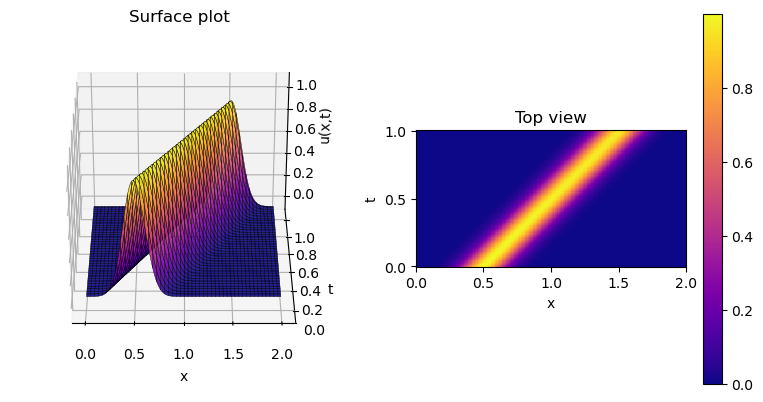

In [7]:
# Dati del problema
c0 = lambda x : np.exp(-40*(x-0.5)**2)
f  = lambda c : c
df = lambda c : 1

h = 0.01
dtlim = h/df(1)
L = 2
T = 1

xc, t, c_sol = fv_solve(c0, f, df, L, T, h, dtlim*0.9, upwind_flux)
plt.figure()
xtplot(xc,t,c_sol,'surface')
plt.show()

#### **(3d) (2 punti) [P+T]**

Calcolare la soluzione esatta al tempo finale $t=T=1$. Confrontare graficamente la soluzione esatta e quella numerica al tempo finale. Commentare il risultato ottenuto.

##### **Soluzione.**

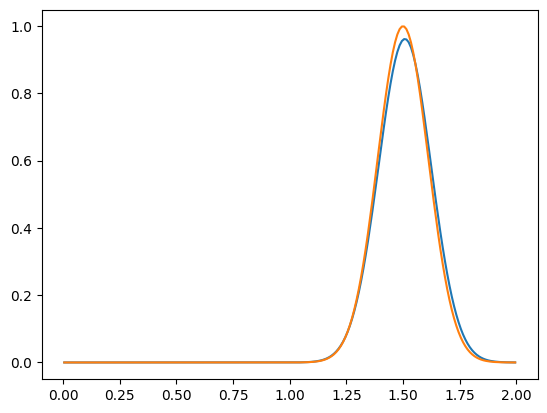

In [18]:
plt.plot(xc, c_sol[:,-1])
plt.plot(xc, c0(xc-1))